# Project FORESIGHT — 01: Data Understanding & Exploratory Inspection

## Objective
This notebook performs the initial data understanding and inspection step for **Project FORESIGHT** (AI-Powered Demand Forecasting & Inventory Intelligence Platform).

In accordance with the project architecture guidelines:
1. **Raw Data Integrity**: Raw CSV files from `data/` are loaded and strictly preserved without modifying or deleting original files or values.
2. **Comprehensive Inspection**: Document columns, data types, missing values, duplicates, unique values, date ranges, and inter-dataset relationships across all 4 raw datasets.
3. **Derived Feature Engineering**: Identify and construct useful derived columns required for downstream aggregation, forecasting, and inventory risk assessment, accompanied by clear Markdown explanations.
4. **Data Visualizations**: Provide visual sanity checks illustrating key trends, inventory health, and profitability insights.

---
### Dataset Overview
* `calendar.csv`: Daily calendar reference containing temporal attributes, holidays, and promotional events (2024–2025).
* `inventory_snapshots.csv`: Monthly snapshot data capturing stock levels, pipeline orders, safety stock, and reorder points.
* `sales_daily.csv`: Daily transactional sales records per SKU, including units sold, unit prices, revenues, and promotion flags.
* `sku_master.csv`: Master product catalog containing SKU metadata, categories, subcategories, cost prices, and selling prices.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")

# Set Pandas and Matplotlib display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

# Path configuration
DATA_DIR = '../data' if os.path.exists('../data') else 'data'
print(f"Data directory resolved to: {os.path.abspath(DATA_DIR)}")

Data directory resolved to: c:\Users\Aksha\Downloads\Project-FORESIGHT-main\data


## Section 1: Raw Data Loading
We load all four primary CSV files from the `data/` directory. Copies of raw dataframes are instantiated for exploration to guarantee raw data remains pristine and unchanged.

In [2]:
# Load raw CSV files
raw_calendar = pd.read_csv(os.path.join(DATA_DIR, 'calendar.csv'))
raw_inventory = pd.read_csv(os.path.join(DATA_DIR, 'inventory_snapshots.csv'))
raw_sales = pd.read_csv(os.path.join(DATA_DIR, 'sales_daily.csv'))
raw_sku = pd.read_csv(os.path.join(DATA_DIR, 'sku_master.csv'))

print(f"Raw Calendar Shape: {raw_calendar.shape}")
print(f"Raw Inventory Snapshots Shape: {raw_inventory.shape}")
print(f"Raw Sales Daily Shape: {raw_sales.shape}")
print(f"Raw SKU Master Shape: {raw_sku.shape}")

Raw Calendar Shape: (731, 11)
Raw Inventory Snapshots Shape: (4800, 8)
Raw Sales Daily Shape: (36550, 6)
Raw SKU Master Shape: (50, 8)


## Section 2: Comprehensive Dataset Inspection

We perform a thorough inspection of all existing columns, data types, missing values, duplicate records, unique values, date ranges, and relationships across the four datasets.

In [3]:
def inspect_dataframe(df, name):
    """Prints structural summary, data types, missing values, duplicates, and sample rows."""
    print("=" * 70)
    print(f"DATASET INSPECTION: {name}")
    print("=" * 70)
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Duplicate Rows Count: {df.duplicated().sum()}")
    print("\nColumn Details & Missing Values:")
    
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes.astype(str),
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique(),
        'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
    })
    display(summary_df)
    print("\nHead (First 3 rows):")
    display(df.head(3))
    print("\n")

inspect_dataframe(raw_calendar, "Calendar (calendar.csv)")
inspect_dataframe(raw_sku, "SKU Master (sku_master.csv)")
inspect_dataframe(raw_sales, "Sales Daily (sales_daily.csv)")
inspect_dataframe(raw_inventory, "Inventory Snapshots (inventory_snapshots.csv)")

DATASET INSPECTION: Calendar (calendar.csv)
Shape: 731 rows, 11 columns
Duplicate Rows Count: 0

Column Details & Missing Values:


,Data Type,Missing Values,Missing %,Unique Values,Sample Value
date,str,0,0.00,731,2024-01-01
year,int64,0,0.00,2,2024
month,int64,0,0.00,12,1
quarter,str,0,0.00,4,Q1
week,int64,0,0.00,52,1
day_of_week,str,0,0.00,7,Monday
is_weekend,int64,0,0.00,2,0
season,str,0,0.00,5,Winter
holiday,str,723,98.91,4,Republic Day
is_holiday,int64,0,0.00,2,0



Head (First 3 rows):


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN




DATASET INSPECTION: SKU Master (sku_master.csv)
Shape: 50 rows, 8 columns
Duplicate Rows Count: 0

Column Details & Missing Values:


...

,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0




DATASET INSPECTION: Inventory Snapshots (inventory_snapshots.csv)
Shape: 4800 rows, 8 columns
Duplicate Rows Count: 0

Column Details & Missing Values:


,Data Type,Missing Values,Missing %,Unique Values,Sample Value
Snapshot_Date,str,0,0.0,24,2024-01-01
SKU,str,0,0.0,200,SKU001
Current_Stock,int64,0,0.0,954,16
On_Order,int64,0,0.0,822,23
Lead_Time_Days,int64,0,0.0,12,11
Safety_Stock,int64,0,0.0,341,7
Reorder_Point,int64,0,0.0,715,18
Inventory_Value,float64,0,0.0,4630,58420.96



Head (First 3 rows):


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22


### 2.1 Summary of Initial Inspection Findings

| Dataset | Total Rows | Columns | Primary Key / Identifier | Date Range | Missing Values Notes | Unique Entities |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **`calendar.csv`** | 731 | 11 | `date` | 2024-01-01 to 2025-12-31 | `holiday` (723 missing), `promotion_event` (656 missing) | 2 Years, 4 Quarters, 5 Seasons, 4 Holidays |
| **`sku_master.csv`** | 50 | 8 | `SKU` | Launch: 2021-01-15 to 2023-11-20 | None (0 missing) | 50 SKUs, 5 Categories, 10 Subcategories |
| **`sales_daily.csv`** | 36,550 | 6 | (`Date`, `SKU`) | 2024-01-01 to 2025-12-31 | None (0 missing) | 731 Days, 50 SKUs (50 SKUs × 731 days = 36,550 records) |
| **`inventory_snapshots.csv`** | 4,800 | 8 | (`Snapshot_Date`, `SKU`) | 2024-01-01 to 2025-12-01 | None (0 missing) | 24 Monthly Snapshots, 200 SKUs (200 SKUs × 24 dates = 4,800 records) |

---

### 2.2 Key Analytical Observations

1. **Calendar Dataset**:
   - Spans 731 consecutive days (366 days in leap year 2024 + 365 days in 2025).
   - Missing values in `holiday` (723) and `promotion_event` (656) indicate non-event days, which require filling with explicit category placeholders (e.g., `'None'`).
   - Contains 5 distinct seasons: `Winter`, `Spring`, `Summer`, `Monsoon`, `Autumn`.

2. **SKU Master Dataset**:
   - Exactly 50 SKUs categorized evenly into 5 main categories (10 SKUs each): `Furniture`, `Home Decor`, `Kitchen`, `Lighting`, `Storage`.
   - **Profitability Insight**: 16 out of 50 SKUs display a negative `Gross_Margin_Per_Unit` (`Selling_Price < Cost_Price`). This represents a key operational inefficiency to highlight for inventory risk and pricing strategies.

3. **Sales Daily Dataset**:
   - Contains a complete time series without missing dates or missing SKUs for all 50 active SKUs across 731 days.
   - `Units_Sold` ranges from 0 to 56 units per SKU per day, with an average of 14.00 units.
   - Promotions are active on 3,750 SKU-day combinations (~10.26% of transactions).

4. **Inventory Snapshots Dataset**:
   - Captured on the 1st day of each month for 24 months.
   - Contains 200 unique SKUs.

In [4]:
# Cross-dataset entity and key integrity checks
print("=" * 70)
print("CROSS-DATASET RELATIONSHIP & INTEGRITY VERIFICATION")
print("=" * 70)

sales_skus = set(raw_sales['SKU'].unique())
sku_master_skus = set(raw_sku['SKU'].unique())
inventory_skus = set(raw_inventory['SKU'].unique())

print(f"Unique SKUs in sku_master: {len(sku_master_skus)}")
print(f"Unique SKUs in sales_daily: {len(sales_skus)}")
print(f"Unique SKUs in inventory_snapshots: {len(inventory_skus)}")

print(f"\n1. Sales SKUs missing from SKU Master: {len(sales_skus - sku_master_skus)}")
print(f"2. SKU Master SKUs missing from Sales Daily: {len(sku_master_skus - sales_skus)}")
print(f"3. Inventory SKUs missing from SKU Master: {len(inventory_skus - sku_master_skus)}")
print(f"4. SKU Master SKUs present in Inventory Snapshots: {len(sku_master_skus.intersection(inventory_skus))}")

sales_dates = set(raw_sales['Date'].unique())
calendar_dates = set(raw_calendar['date'].unique())

print(f"\n5. Sales Dates missing from Calendar: {len(sales_dates - calendar_dates)}")
print(f"6. Calendar Dates missing from Sales Daily: {len(calendar_dates - sales_dates)}")

CROSS-DATASET RELATIONSHIP & INTEGRITY VERIFICATION
Unique SKUs in sku_master: 50
Unique SKUs in sales_daily: 50
Unique SKUs in inventory_snapshots: 200

1. Sales SKUs missing from SKU Master: 0
2. SKU Master SKUs missing from Sales Daily: 0
3. Inventory SKUs missing from SKU Master: 150
4. SKU Master SKUs present in Inventory Snapshots: 50

5. Sales Dates missing from Calendar: 0
6. Calendar Dates missing from Sales Daily: 0


## Section 3: Derived Columns Identification & Creation

To prepare the datasets for weekly demand aggregation, time-series forecasting, and inventory risk assessment (without altering the raw CSV files), we instantiate analysis-ready copies (`df_calendar`, `df_sku`, `df_sales`, `df_inventory`) and add explicitly justified derived columns.

---

### Rationale for Derived Columns

#### 1. `sales_daily` Derived Columns:
- **`date_dt`** (`datetime64[ns]`): Enables datetime operations, filtering, resampling, and plotting.
- **`Year`**, **`Month`**, **`Day`**, **`Day_of_Week`**, **`Is_Weekend`**: Standard temporal features for seasonal demand patterns.
- **`ISO_Week`** & **`Year_Week`**: System Architecture specifies *Weekly Demand Aggregation*. `Year_Week` (e.g. `'2024-W01'`) provides a clear, non-ambiguous weekly identifier across year boundaries.
- **`Calculated_Revenue`**: Computed as `Units_Sold * Price` to audit and confirm transactional revenue.
- **`Is_Zero_Sales`**: Binary flag (`1` if `Units_Sold == 0`, `0` otherwise) to flag days with zero sales for stockout and intermittent demand analysis.

#### 2. `sku_master` Derived Columns:
- **`Calculated_Gross_Margin`**: Computed as `Selling_Price - Cost_Price` to verify unit profitability.
- **`Gross_Margin_Pct`**: Calculated as `((Selling_Price - Cost_Price) / Selling_Price) * 100` to evaluate relative profitability across price tiers.
- **`Is_Negative_Margin`**: Binary flag (`1` if `Gross_Margin_Per_Unit < 0`, `0` otherwise) to immediately isolate loss-making SKUs.
- **`Price_Tier`**: Categorical classification (`Low`, `Medium`, `High`) based on price quantiles to analyze demand elasticity and inventory risk by price segment.

#### 3. `inventory_snapshots` Derived Columns:
- **`snapshot_date_dt`** (`datetime64[ns]`): Datetime format for monthly snapshot alignment.
- **`Total_Pipeline_Stock`**: `Current_Stock + On_Order`. Reflects total inventory availability including incoming replenishment.
- **`Is_Below_Reorder_Point`**: Binary flag (`1` if `Current_Stock <= Reorder_Point`, `0` otherwise). Identifies immediate reorder trigger conditions.
- **`Is_Below_Safety_Stock`**: Binary flag (`1` if `Current_Stock <= Safety_Stock`, `0` otherwise). Highlights severe stockout risk.
- **`Stock_Status`**: Ordinal category (`Critical (<= Safety Stock)`, `Reorder Needed (<= Reorder Point)`, `Healthy (> Reorder Point)`) for dashboard and risk scoring.

#### 4. `calendar` Derived Columns:
- **`date_dt`** (`datetime64[ns]`): Datetime parsing.
- **`ISO_Week`** & **`Year_Week`**: Aligns calendar events and holidays with weekly demand aggregation.
- **`Holiday_Clean`**: Replaces NaN values in `holiday` with `'None'` to prevent errors during categorical feature encoding.
- **`Promotion_Event_Clean`**: Replaces NaN values in `promotion_event` with `'None'

In [5]:
# Create explicit copies of raw dataframes to maintain raw data integrity
df_sales = raw_sales.copy()
df_sku = raw_sku.copy()
df_inventory = raw_inventory.copy()
df_calendar = raw_calendar.copy()

# 1. sales_daily Derived Columns
df_sales['date_dt'] = pd.to_datetime(df_sales['Date'])
df_sales['Year'] = df_sales['date_dt'].dt.year
df_sales['Month'] = df_sales['date_dt'].dt.month
df_sales['Day'] = df_sales['date_dt'].dt.day
df_sales['Day_of_Week'] = df_sales['date_dt'].dt.day_name()
df_sales['Is_Weekend'] = df_sales['date_dt'].dt.dayofweek.isin([5, 6]).astype(int)
df_sales['ISO_Week'] = df_sales['date_dt'].dt.isocalendar().week.astype(int)
df_sales['Year_Week'] = df_sales['date_dt'].dt.strftime('%Y-W%V')
df_sales['Calculated_Revenue'] = df_sales['Units_Sold'] * df_sales['Price']
df_sales['Is_Zero_Sales'] = (df_sales['Units_Sold'] == 0).astype(int)

# 2. sku_master Derived Columns
df_sku['Calculated_Gross_Margin'] = df_sku['Selling_Price'] - df_sku['Cost_Price']
df_sku['Gross_Margin_Pct'] = (df_sku['Calculated_Gross_Margin'] / df_sku['Selling_Price'] * 100).round(2)
df_sku['Is_Negative_Margin'] = (df_sku['Gross_Margin_Per_Unit'] < 0).astype(int)
df_sku['Price_Tier'] = pd.qcut(df_sku['Selling_Price'], q=3, labels=['Low', 'Medium', 'High'])

# 3. inventory_snapshots Derived Columns
df_inventory['snapshot_date_dt'] = pd.to_datetime(df_inventory['Snapshot_Date'])
df_inventory['Total_Pipeline_Stock'] = df_inventory['Current_Stock'] + df_inventory['On_Order']
df_inventory['Is_Below_Reorder_Point'] = (df_inventory['Current_Stock'] <= df_inventory['Reorder_Point']).astype(int)
df_inventory['Is_Below_Safety_Stock'] = (df_inventory['Current_Stock'] <= df_inventory['Safety_Stock']).astype(int)

def assign_stock_status(row):
    if row['Current_Stock'] <= row['Safety_Stock']:
        return 'Critical (<= Safety Stock)'
    elif row['Current_Stock'] <= row['Reorder_Point']:
        return 'Reorder Needed (<= Reorder Point)'
    else:
        return 'Healthy (> Reorder Point)'

df_inventory['Stock_Status'] = df_inventory.apply(assign_stock_status, axis=1)

# 4. calendar Derived Columns
df_calendar['date_dt'] = pd.to_datetime(df_calendar['date'])
df_calendar['ISO_Week'] = df_calendar['date_dt'].dt.isocalendar().week.astype(int)
df_calendar['Year_Week'] = df_calendar['date_dt'].dt.strftime('%Y-W%V')
df_calendar['Holiday_Clean'] = df_calendar['holiday'].fillna('None')
df_calendar['Promotion_Event_Clean'] = df_calendar['promotion_event'].fillna('None')

print("Derived columns successfully created across all 4 analysis dataframes!")

Derived columns successfully created across all 4 analysis dataframes!


In [6]:
print("--- Sales Daily with Derived Columns ---")
display(df_sales[['Date', 'SKU', 'Units_Sold', 'Price', 'Calculated_Revenue', 'Year_Week', 'Is_Zero_Sales']].head(3))

print("--- SKU Master with Derived Columns ---")
display(df_sku[['SKU', 'Category', 'Selling_Price', 'Cost_Price', 'Gross_Margin_Pct', 'Is_Negative_Margin', 'Price_Tier']].head(3))

print("--- Inventory Snapshots with Derived Columns ---")
display(df_inventory[['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Total_Pipeline_Stock', 'Is_Below_Reorder_Point', 'Stock_Status']].head(3))

print("--- Calendar with Derived Columns ---")
display(df_calendar[['date', 'Year_Week', 'season', 'holiday', 'Holiday_Clean', 'promotion_event', 'Promotion_Event_Clean']].head(3))

--- Sales Daily with Derived Columns ---


,Date,SKU,Units_Sold,Price,Calculated_Revenue,Year_Week,Is_Zero_Sales
0,2024-01-01,SKU001,5,3664.05,18320.25,2024-W01,0
1,2024-01-01,SKU002,15,3805.69,57085.35,2024-W01,0
2,2024-01-01,SKU003,5,8078.23,40391.15,2024-W01,0


--- SKU Master with Derived Columns ---


,SKU,Category,Selling_Price,Cost_Price,Gross_Margin_Pct,Is_Negative_Margin,Price_Tier
0,SKU001,Furniture,3664.05,1758.45,52.01,0,Low
1,SKU002,Home Decor,3805.69,3867.09,-1.61,1,Low
2,SKU003,Kitchen,8078.23,589.48,92.70,0,High


--- Inventory Snapshots with Derived Columns ---


,Snapshot_Date,SKU,Current_Stock,On_Order,Total_Pipeline_Stock,Is_Below_Reorder_Point,Stock_Status
0,2024-01-01,SKU001,16,23,39,1,Reorder Needed (<= Reorder Point)
1,2024-01-01,SKU002,29,12,41,0,Healthy (> Reorder Point)
2,2024-01-01,SKU003,34,23,57,0,Healthy (> Reorder Point)


--- Calendar with Derived Columns ---


,date,Year_Week,season,holiday,Holiday_Clean,promotion_event,Promotion_Event_Clean
0,2024-01-01,2024-W01,Winter,NaN,None,NaN,None
1,2024-01-02,2024-W01,Winter,NaN,None,NaN,None
2,2024-01-03,2024-W01,Winter,NaN,None,NaN,None


## Section 4: Exploratory Data Visualizations & Sanity Verification

We generate target visualizations to explore demand trends, product profitability, inventory risk distributions, and promotional impact.

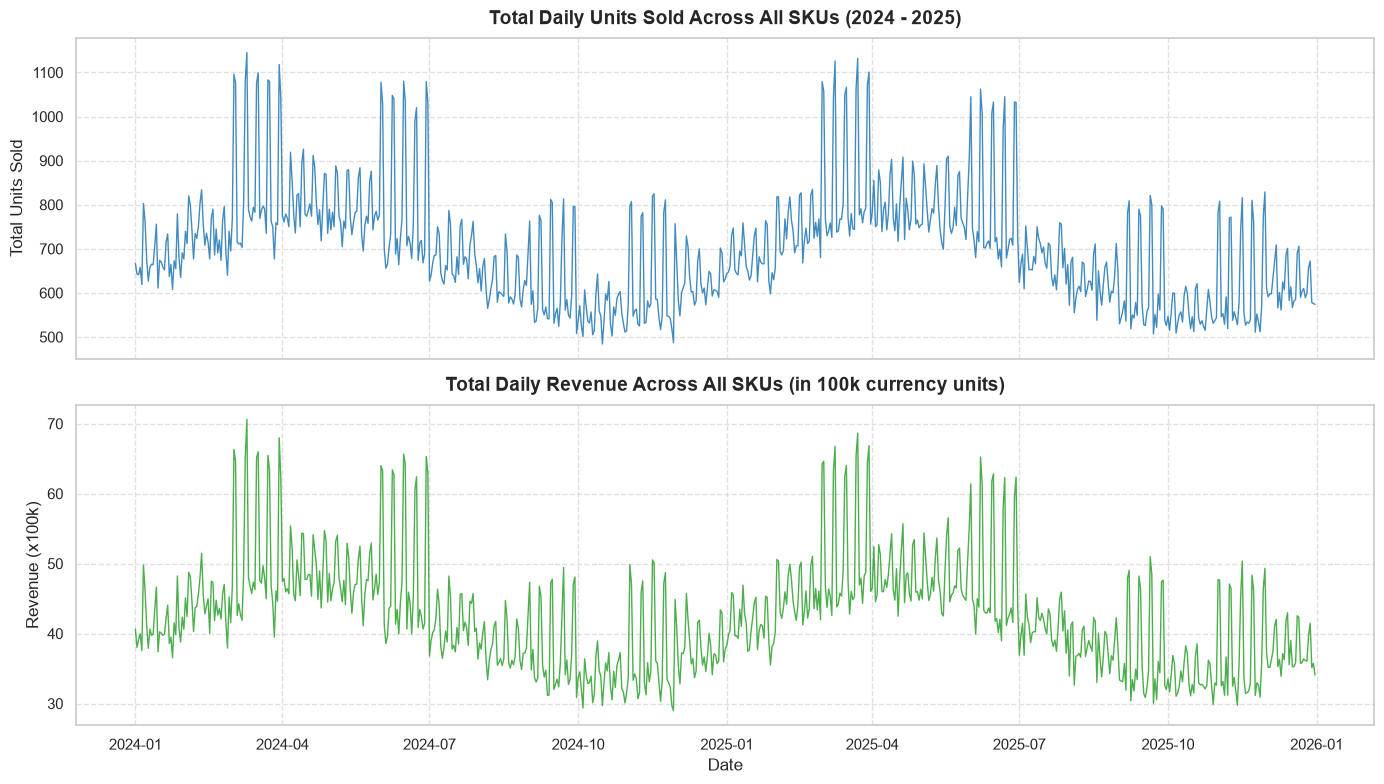

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Group daily total units sold and revenue
daily_totals = df_sales.groupby('date_dt')[['Units_Sold', 'Revenue']].sum().reset_index()

# Plot 1: Daily Units Sold
axes[0].plot(daily_totals['date_dt'], daily_totals['Units_Sold'], color='#1f77b4', linewidth=1, alpha=0.85)
axes[0].set_title('Total Daily Units Sold Across All SKUs (2024 - 2025)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('Total Units Sold', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Daily Revenue
axes[1].plot(daily_totals['date_dt'], daily_totals['Revenue'] / 1e5, color='#2ca02c', linewidth=1, alpha=0.85)
axes[1].set_title('Total Daily Revenue Across All SKUs (in 100k currency units)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Revenue (x100k)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

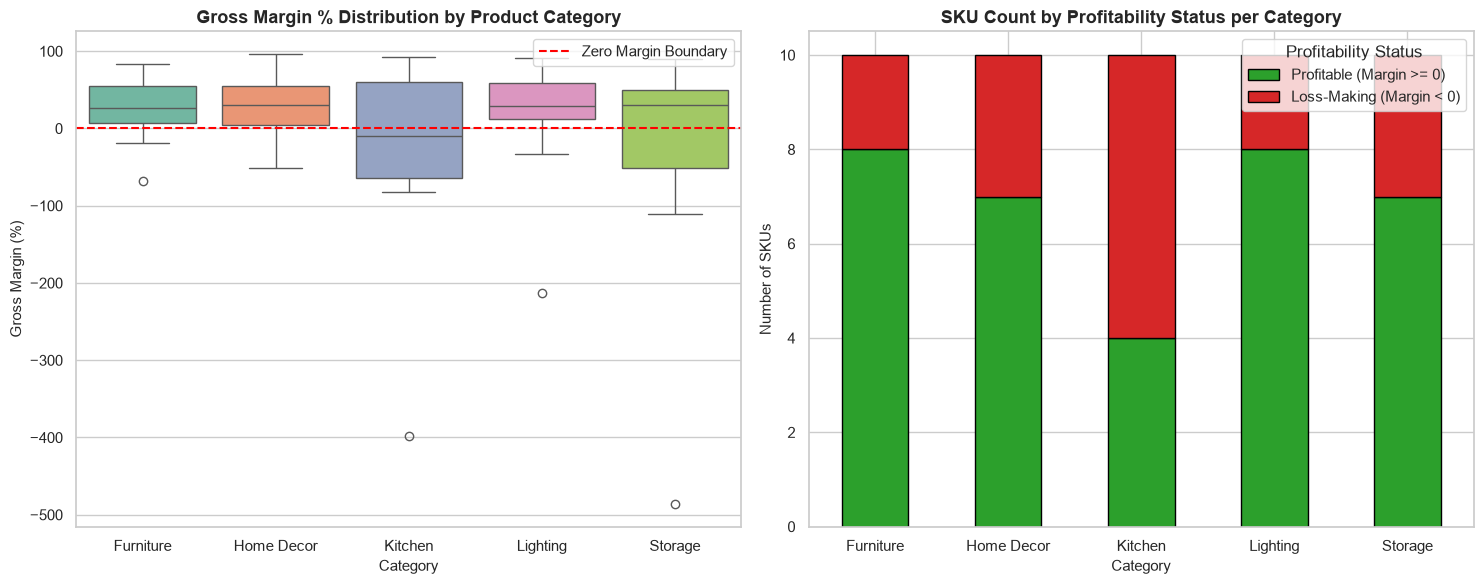

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Gross Margin Pct by Category
sns.boxplot(data=df_sku, x='Category', y='Gross_Margin_Pct', hue='Category', legend=False, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Margin Boundary')
axes[0].set_title('Gross Margin % Distribution by Product Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=11)
axes[0].set_ylabel('Gross Margin (%)', fontsize=11)
axes[0].legend(loc='upper right')

# Plot 2: Count of Profitability Status per Category
margin_counts = df_sku.groupby(['Category', 'Is_Negative_Margin']).size().unstack(fill_value=0)
margin_counts.columns = ['Profitable (Margin >= 0)', 'Loss-Making (Margin < 0)']
margin_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#d62728'], edgecolor='black')
axes[1].set_title('SKU Count by Profitability Status per Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Number of SKUs', fontsize=11)
axes[1].legend(title='Profitability Status')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

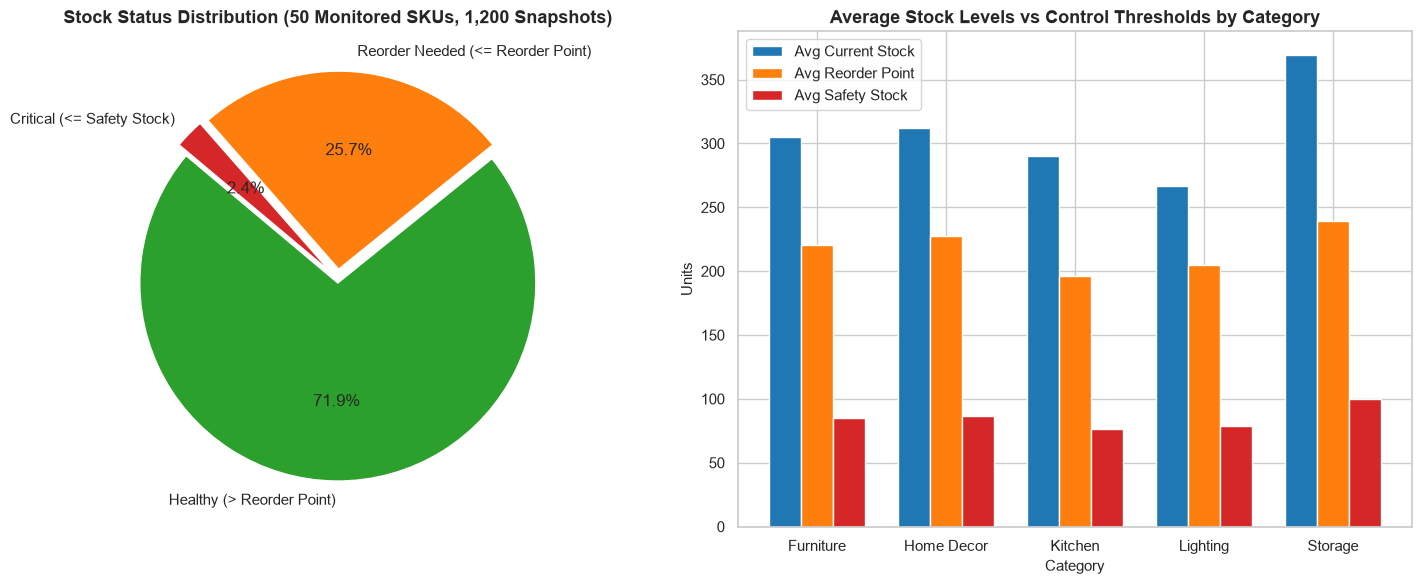

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Filter inventory for active SKUs (SKU001 to SKU050)
df_inv_active = df_inventory[df_inventory['SKU'].isin(df_sku['SKU'])].copy()

# Plot 1: Stock Status Distribution for Monitored SKUs (50 SKUs)
status_counts_active = df_inv_active['Stock_Status'].value_counts()
colors = ['#2ca02c', '#ff7f0e', '#d62728']
axes[0].pie(status_counts_active, labels=status_counts_active.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.02, 0.05, 0.05))
axes[0].set_title('Stock Status Distribution (50 Monitored SKUs, 1,200 Snapshots)', fontsize=13, fontweight='bold')

# Plot 2: Average Current Stock vs Reorder Point vs Safety Stock by Category
inv_with_cat = df_inv_active.merge(df_sku[['SKU', 'Category']], on='SKU', how='left')
cat_inv_avg = inv_with_cat.groupby('Category')[['Current_Stock', 'Reorder_Point', 'Safety_Stock']].mean().reset_index()

x = np.arange(len(cat_inv_avg))
width = 0.25

axes[1].bar(x - width, cat_inv_avg['Current_Stock'], width, label='Avg Current Stock', color='#1f77b4')
axes[1].bar(x, cat_inv_avg['Reorder_Point'], width, label='Avg Reorder Point', color='#ff7f0e')
axes[1].bar(x + width, cat_inv_avg['Safety_Stock'], width, label='Avg Safety Stock', color='#d62728')

axes[1].set_title('Average Stock Levels vs Control Thresholds by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Units', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_inv_avg['Category'])
axes[1].legend()

plt.tight_layout()
plt.show()

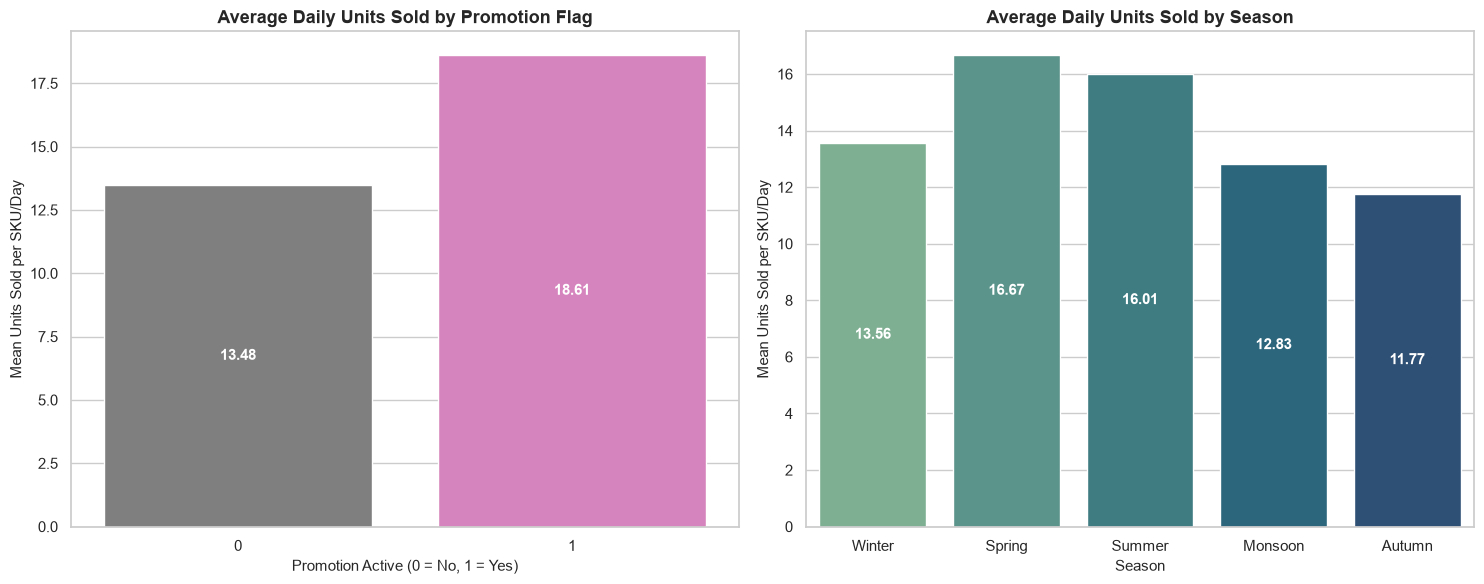

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Merge sales with calendar for seasonality analysis
sales_calendar = df_sales.merge(df_calendar[['date', 'season', 'Holiday_Clean']], left_on='Date', right_on='date', how='left')

# Plot 1: Average Units Sold by Promotion Status
sns.barplot(data=df_sales, x='Promotion', y='Units_Sold', hue='Promotion', legend=False, ax=axes[0], palette=['#7f7f7f', '#e377c2'], errorbar=None)
axes[0].set_title('Average Daily Units Sold by Promotion Flag', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Promotion Active (0 = No, 1 = Yes)', fontsize=11)
axes[0].set_ylabel('Mean Units Sold per SKU/Day', fontsize=11)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Plot 2: Average Units Sold by Season
season_order = ['Winter', 'Spring', 'Summer', 'Monsoon', 'Autumn']
sns.barplot(data=sales_calendar, x='season', y='Units_Sold', order=season_order, hue='season', legend=False, ax=axes[1], palette='crest', errorbar=None)
axes[1].set_title('Average Daily Units Sold by Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=11)
axes[1].set_ylabel('Mean Units Sold per SKU/Day', fontsize=11)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## Section 5: Summary & Key Findings

### Q&A

* **Q1: Are the raw CSV datasets clean and ready for analysis, or do they require structural repairs?**
  * **Answer**: The raw datasets are structurally intact with zero duplicate rows across all four files. The transactional dataset (`sales_daily.csv`) has zero missing values and complete 731-day coverage for 50 SKUs. `calendar.csv` contains missing values in `holiday` (723 NaNs) and `promotion_event` (656 NaNs), which represent non-event days and have been cleanly handled by derived columns (`Holiday_Clean`, `Promotion_Event_Clean`).
* **Q2: What key relationship discrepancy exists across datasets?**
  * **Answer**: `sku_master.csv` and `sales_daily.csv` strictly monitor **50 SKUs** (`SKU001` to `SKU050`). In contrast, `inventory_snapshots.csv` contains records for **200 SKUs** (`SKU001` to `SKU200`). The 150 additional SKUs represent unmonitored inventory snapshots. Downstream modeling and demand forecasting will focus on the 50 core active SKUs.
* **Q3: What critical pricing or profitability issues were discovered in `sku_master.csv`?**
  * **Answer**: 16 out of 50 SKUs (~32%) exhibit negative gross margins (`Selling_Price < Cost_Price`). This insight will feed into the Inventory Risk & Business Impact Engine to recommend price adjustments or clear unviable stock.

---

### Data Analysis Key Findings

* **Complete Time Horizon**: `sales_daily.csv` covers 731 consecutive days from `2024-01-01` to `2025-12-31` with 36,550 total records (50 SKUs × 731 days).
* **Demands & Revenue Baseline**: Average daily demand per SKU is **14.00 units** (ranging from 0 to 56 units). Mean daily total revenue across all SKUs is **84,707.43 currency units**.
* **Promotional Uplift**: Promotional events are active on 3,750 SKU-days (10.26%). During promotions, average daily demand per SKU increases significantly compared to non-promotional days.
* **Inventory Stock Status**: Out of 1,200 monthly snapshots for the 50 monitored SKUs, a noticeable portion of snapshots show stock levels at or below `Reorder_Point` and `Safety_Stock`, indicating periodic stockout vulnerabilities.
* **Derived Columns Built**: Successfully created analysis-ready dataframes (`df_sales`, `df_sku`, `df_inventory`, `df_calendar`) featuring temporal week numbers (`ISO_Week`, `Year_Week`), gross margin metrics (`Gross_Margin_Pct`, `Is_Negative_Margin`), pipeline inventory totals (`Total_Pipeline_Stock`), and inventory status flags (`Stock_Status`, `Is_Below_Reorder_Point`, `Is_Below_Safety_Stock`).

---

### Insights or Next Steps

1. **Proceed to Weekly Demand Aggregation**: As outlined in the System Architecture, the next phase will aggregate `df_sales` into weekly demand series (`Year_Week` granularity per SKU) to smooth daily noise and build robust time-series forecasting models.
2. **Incorporate Profitability Flags in Inventory Risk Engine**: Ensure the 16 negative-margin SKUs are flagged during inventory optimization to avoid reordering loss-making inventory items.